<a href="https://colab.research.google.com/github/Supun-Chinthana/Face-recognition-system-using-Tensorflow/blob/main/Face_Recognition_model_Hope_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! pip install kaggle
! pip install cvlib
! pip install mediapipe
!pip install scikit-learn

In [ ]:
import cv2
import numpy as np
import tensorflow as tf
from google.colab import drive
import mediapipe as mp
from cvlib.face_detection import detect_face
import os
import glob
from google.colab.patches import cv2_imshow
import random as rnd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import class_weight

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
scaler = MinMaxScaler()

In [ ]:
drive.mount("Drive")

In [ ]:
! mkdir ~/.kaggle

In [ ]:
! ren kaggle(2).json kaggle.json

In [ ]:
! cp kaggle.json ~/.kaggle/

In [ ]:
! chmod 600 ~/.kaggle/kaggle.json

In [ ]:
! kaggle datasets download -d ashwingupta3012/male-and-female-faces-dataset

In [ ]:
! unzip /content/male-and-female-faces-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Male and Female face dataset/Female Faces/0 (1367).jpg  
  inflating: Male and Female face dataset/Female Faces/0 (1368).jpg  
  inflating: Male and Female face dataset/Female Faces/0 (1369).jpg  
  inflating: Male and Female face dataset/Female Faces/0 (137).jpg  
  inflating: Male and Female face dataset/Female Faces/0 (1370).jpg  
  inflating: Male and Female face dataset/Female Faces/0 (1371).jpg  
  inflating: Male and Female face dataset/Female Faces/0 (1372).jpg  
  inflating: Male and Female face dataset/Female Faces/0 (1373).jpg  
  inflating: Male and Female face dataset/Female Faces/0 (1374).jpg  
  inflating: Male and Female face dataset/Female Faces/0 (1375).jpg  
  inflating: Male and Female face dataset/Female Faces/0 (1376).jpg  
  inflating: Male and Female face dataset/Female Faces/0 (1377).jpg  
  inflating: Male and Female face dataset/Female Faces/0 (1378).jpg  
  inflating: Male and Female face datase

In [ ]:
root_dir_male = "/content/Male and Female face dataset/Male Faces"
root_dir_female = "/content/Male and Female face dataset/Female Faces"

male_paths = sorted(os.listdir("/content/Male and Female face dataset/Male Faces"))
female_paths = sorted(os.listdir("/content/Male and Female face dataset/Female Faces"))

for i,path in enumerate(male_paths):
  male_paths[i] = os.path.join(root_dir_male,path)

for i, path in enumerate(female_paths):
  female_paths[i] = os.path.join(root_dir_female, path)


In [ ]:
mapped_paths = {}
for path in male_paths:
  mapped_paths[path] = 'male'

for path in female_paths:
  mapped_paths[path] = 'female'

In [ ]:
dataset_images_paths = male_paths + female_paths
dataset_images = []
for path in dataset_images_paths:
  image = cv2.imread(path)
  image = cv2.resize(image, (224,224))
  dataset_images.append(image)

Gather images from video file

                

In [ ]:
path = "/content/Drive/MyDrive/Data/Face recognition video.mp4"
path2 = "/content/Drive/MyDrive/Data/train video 2.mp4"
path3 = "/content/Drive/MyDrive/Data/Train video 3.mp4"

target_face_images = []


cap = cv2.VideoCapture(path)

while True:


  ret, frame = cap.read()

  if ret == False:
    break

  frame = cv2.resize(frame, (224,224))
  target_face_images.append(frame)

cap = cv2.VideoCapture(path2)

while True:

  ret, frame = cap.read()

  if ret == False:
    break

  frame = cv2.resize(frame, (224,224))
  target_face_images.append(frame)


cap = cv2.VideoCapture(path3)

while True:

  ret, frame = cap.read()

  if ret == False:
    break

  frame = cv2.resize(frame, (224,224))
  target_face_images.append(frame)




target_face_images = np.array(target_face_images)
print(target_face_images.shape)

(2495, 224, 224, 3)


In [ ]:
n_copies = 6000
copies_per_images = round(n_copies / target_face_images.shape[0])
new_dataset_images = []

for i, image in enumerate(target_face_images):
 for i in range(copies_per_images):
  image = np.clip(image * round(rnd.uniform(0.4,2.0),1), 0, 255)
  new_dataset_images.append(image)


In [ ]:
dataset_images = np.array(dataset_images)
new_dataset_images = np.array(new_dataset_images)

limit_for_unknown = dataset_images.shape[0]
print(dataset_images.shape)
print(new_dataset_images.shape)

(5418, 224, 224, 3)
(4990, 224, 224, 3)


In [ ]:
my_dataset_images = np.array(list(dataset_images) + list(new_dataset_images))
print(my_dataset_images.shape)

(10408, 224, 224, 3)


In [ ]:
y_axis = np.zeros((my_dataset_images.shape[0],),dtype="float32")
print(y_axis.shape)

y_axis[:limit_for_unknown] = 0.0
y_axis[limit_for_unknown:] = 1.0

(10408,)


In [ ]:
print(my_dataset_images.astype('uint8').shape)
my_dataset_images = my_dataset_images.astype('uint8')
print(my_dataset_images.shape)

(10408, 224, 224, 3)
(10408, 224, 224, 3)


In [ ]:
print(y_axis.shape)

(10408,)


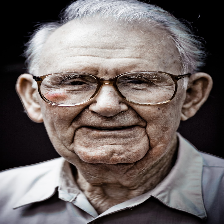

In [ ]:
cv2_imshow(my_dataset_images[0])

In [ ]:
axis_x = []
could_not = []
for i, image in enumerate(my_dataset_images):


  bbox, conf = detect_face(image)
  if bbox:
    specific_arg = np.argmax(conf)


    print(bbox[specific_arg], i, conf[specific_arg])
    image = image[bbox[specific_arg][1]:bbox[specific_arg][3], bbox[specific_arg][0]:bbox[specific_arg][2]]

    if image.size !=0:
      image = cv2.resize(image, (224,224))
      axis_x.append(image)

    else:
      could_not.append(i)

  else:
    could_not.append(i)


y_axis = np.delete(y_axis, could_not)

axis_x = np.array(axis_x)
print(axis_x.shape, y_axis.shape)
print(len(could_not))


Streaming output truncated to the last 5000 lines.
[30, 27, 115, 184] 5326 0.9999782
[77, 42, 167, 124] 5327 0.99993014
[71, 62, 192, 179] 5328 0.99968755
[90, 38, 185, 160] 5329 0.99988234
[32, 17, 180, 158] 5330 0.9994717
[60, 42, 139, 126] 5331 0.99986196
[66, 40, 187, 151] 5332 0.999423
[118, 100, 242, 276] 5333 0.99972445
[86, 59, 143, 197] 5334 0.99980646
[104, 39, 179, 99] 5335 0.98722535
[24, 21, 101, 152] 5336 0.9975903
[47, 29, 163, 127] 5337 0.9999974
[112, 107, 270, 252] 5338 0.99998057
[79, 32, 153, 99] 5339 0.9999777
[53, 43, 170, 153] 5340 0.99997723
[110, 75, 235, 298] 5341 0.9993957
[5, 34, 87, 175] 5342 0.95443225
[42, 39, 167, 156] 5343 0.99991095
[49, 8, 185, 144] 5344 0.9999944
[44, 69, 179, 188] 5345 0.99985003
[57, 61, 169, 170] 5346 0.9998301
[61, 25, 158, 123] 5347 0.9999932
[678, 447, 857, 648] 5348 0.9959573
[75, 23, 169, 116] 5349 0.99907243
[9, 5, 168, 162] 5350 0.99837863
[80, 34, 163, 129] 5351 0.99993896
[60, 42, 162, 181] 5352 0.99984324
[52, 66, 181, 1

In [ ]:
axis_x.shape

(10094, 224, 224, 3)

In [ ]:
my_dataset_images = axis_x

In [ ]:
my_dataset_images = list(my_dataset_images)
y_axis = list(y_axis)

zipped = list(zip(my_dataset_images, y_axis))
rnd.shuffle(zipped)

my_dataset_images, y_axis = zip(*zipped)

my_dataset_images = np.array(list(my_dataset_images))
y_axis = np.array(list(y_axis))

print(my_dataset_images.shape)

(10094, 224, 224, 3)


In [ ]:
x_split_idx = round(my_dataset_images.shape[0] * 0.80)
y_split_idx = round(y_axis.shape[0] * 0.8)

X_train = my_dataset_images[:x_split_idx]
Y_train = y_axis[:y_split_idx]

X_test = my_dataset_images[x_split_idx:]
Y_test = y_axis[y_split_idx:]

print(X_train.shape,Y_train.shape)
print(X_test.shape, Y_test.shape)

(8075, 224, 224, 3) (8075,)
(2019, 224, 224, 3) (2019,)


In [ ]:
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

In [ ]:
model = tf.keras.models.Sequential(name="Hope")
model.add(tf.keras.layers.Conv2D(16, (3,3), strides=(1,1), padding="same", activation="relu", input_shape=my_dataset_images[0].shape))
model.add(tf.keras.layers.MaxPooling2D((2,2), strides=(2,2), padding="same"))
model.add(tf.keras.layers.Dropout(0.3))

model.add(tf.keras.layers.Conv2D(32, (3,3), strides=(1,1), padding="same", activation="relu"))
model.add(tf.keras.layers.MaxPooling2D((2,2), strides=(2,2), padding="same"))
model.add(tf.keras.layers.Dropout(0.2))

model.add(tf.keras.layers.Conv2D(64, (3,3), strides=(1,1), padding="same", activation="relu"))
model.add(tf.keras.layers.MaxPooling2D((2,2), strides=(2,2), padding="same"))
model.add(tf.keras.layers.Dropout(0.1))

model.add(tf.keras.layers.Flatten())

model.add(tf.keras.layers.Dense(128, activation="relu", kernel_initializer=tf.keras.initializers.random_uniform()))
model.add(tf.keras.layers.Dense(1, activation="sigmoid"))

model.summary()

Model: "Hope"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 224, 224, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2  (None, 112, 112, 16)      0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 112, 112, 16)      0         
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 32)      4640      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 56, 56, 32)        0         
 g2D)                                                            
                                                                 
 dropout_1 (Dropout)         (None, 56, 56, 32)        0      

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])

In [ ]:
history = model.fit(X_train, Y_train, epochs=100, batch_size=64,validation_split=0.1, callbacks=[early_stopping, lr_scheduler])

Epoch 1/100
114/114 [==============================] - 48s 406ms/step - loss: 0.4823 - accuracy: 0.8413 - val_loss: 0.1326 - val_accuracy: 0.9616 - lr: 0.0010
Epoch 2/100
114/114 [==============================] - 45s 398ms/step - loss: 0.0564 - accuracy: 0.9828 - val_loss: 0.0500 - val_accuracy: 0.9851 - lr: 0.0010
Epoch 3/100
114/114 [==============================] - 45s 399ms/step - loss: 0.0336 - accuracy: 0.9889 - val_loss: 0.0287 - val_accuracy: 0.9938 - lr: 0.0010
Epoch 4/100
114/114 [==============================] - 45s 399ms/step - loss: 0.0475 - accuracy: 0.9839 - val_loss: 0.0213 - val_accuracy: 0.9926 - lr: 0.0010
Epoch 5/100
114/114 [==============================] - 45s 394ms/step - loss: 0.0136 - accuracy: 0.9952 - val_loss: 0.0128 - val_accuracy: 0.9963 - lr: 0.0010
Epoch 6/100
114/114 [==============================] - 45s 395ms/step - loss: 0.0070 - accuracy: 0.9978 - val_loss: 0.0071 - val_accuracy: 0.9975 - lr: 0.0010
Epoch 7/100
114/114 [=========================

In [ ]:
accuracy = history.history["accuracy"]
loss = history.history["loss"]

val_acc = history.history["val_accuracy"]
val_loss = history.history["val_loss"]

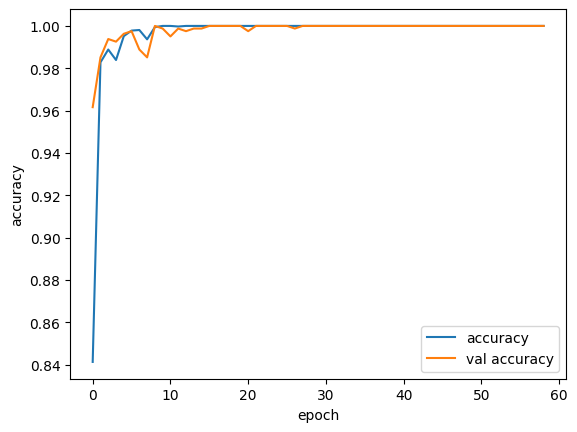

In [ ]:
plt.plot(accuracy, label="accuracy")
plt.plot(val_acc, label="val accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()

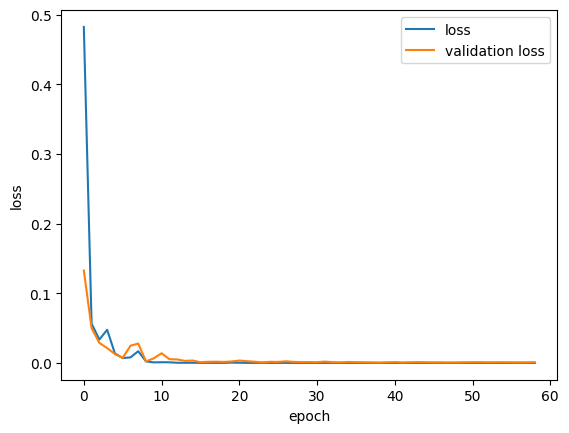

In [ ]:
plt.plot(loss, label="loss")
plt.plot(val_loss, label="validation loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

In [ ]:
model.save("/content/Drive/MyDrive/Data/model_Hope.h5")

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
test = model.predict(X_test)
c = 0
for i, pred in enumerate(test):
  if round(float(pred)) != Y_test[i]:
    print(i,"expected ", Y_test[i], "     got ", round(float(pred)))
    c += 1
print(c)

count = 0
for i in test:
  if round(float(i)) == 1:
    count+=1

count_y = 0
for i in Y_test:
  if i == 1:
    count_y+=1

print("amount of 1s predicted  ",count)
print("amount of 1s in test dataset  ", count_y)

64/64 [==============================] - 3s 38ms/step
1081 expected  0.0      got  1
1841 expected  1.0      got  0
2
amount of 1s predicted   945
amount of 1s in test dataset   945


<ipython-input-55-9273e7e542e1>:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if round(float(pred)) != Y_test[i]:
<ipython-input-55-9273e7e542e1>:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(i,"expected ", Y_test[i], "     got ", round(float(pred)))
<ipython-input-55-9273e7e542e1>:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if round(float(i)) == 1:


In [ ]:
print(X_train.shape)

(8075, 224, 224, 3)
